In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
modul_path = "/work/scheibe5/bacteriophate_t7"
if modul_path not in sys.path:
    sys.path.append(modul_path)
import stochastinetics
import multiprocess

### Model/Parameter Definition

In [2]:
k1 = 0.025
k2 = 0.25
k3 = 1.0
k4 = 7.5*10**(-6)
k5 = 1000
k6 = 1.99
tem0 = 1
gen0 = 0
struc0 = 0
Delta_t = 10**(-3)
delta_t = 10**(-2)
I1 = 25.0
I2 = 35.0
boundaries = np.array([I1,I2,I1,I2,I1,I2])

S = np.array([[-1,0,1,-1,0,0],[1,-1,0,0,0,0],[0,0,0,-1,1,-1]]) # order [gen,tem,struc]
S_ed = np.array([[1,0,0,1,0,0],[0,1,1,0,1,0],[0,0,0,1,0,1]],dtype=int)
c = np.array([k1,k2,k3,k4,k5,k6]) # assuming this are already the volume dependent constants...
x0 = np.array([gen0,tem0,struc0])

### Deterministic

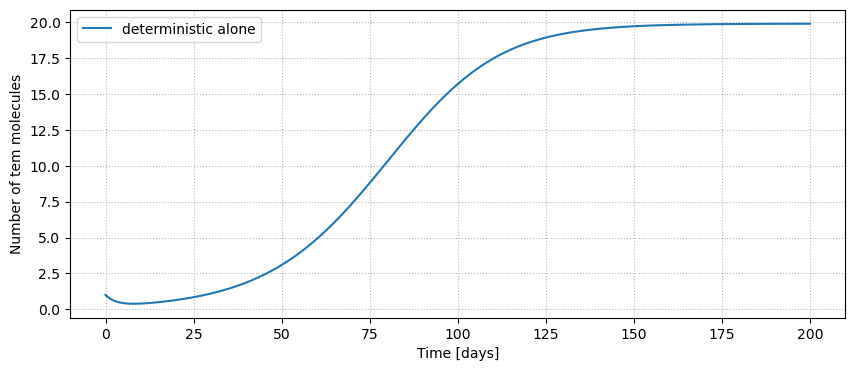

In [3]:
from scipy.integrate import solve_ivp
import numpy as np
from matplotlib import pyplot as plt

def rate_of_change(t,x,S,c):
    gen_dot = -c[0]*x[0] + c[2]*x[1] - c[3]*x[0]*x[2]
    tem_dot = c[0]*x[0]-c[1]*x[1]
    struc_dot = -c[3]*x[0]*x[2] + c[4]*x[1] -c[5]*x[2]
    return gen_dot,tem_dot,struc_dot

t_start = 0
t_end = 200
n1 = 10000
t_eval = np.linspace(t_start, t_end, n1)

bacteriophage = solve_ivp(rate_of_change,(t_start,t_end),x0,t_eval=t_eval,args=(S,c))

tem = bacteriophage.y[1]

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(bacteriophage.t, tem, label="deterministic alone")
ax1.legend()
ax1.set_xlabel("Time [days]")
ax1.set_ylabel("Number of tem molecules")
ax1.grid(True, linestyle=':', color='gray', alpha=0.6)

### Expectation Values

In [ ]:
path_ssa = "/work/scheibe5/bacteriophage_t7/ssa/result_ssa_bacteriophage.csv"
path_duncan = "/work/scheibe5/bacteriophage_t7/duncan_ssa/result_duncan_ssa_15_25_bacteriophage.csv"
path_alfonsi = "/work/scheibe5/bacteriophage_t7/alfonsi_adaptive/result_alfonsi_adaptive_60_bacteriophage.csv"
path_cle = "/work/scheibe5/bacteriophage_t7/cle/result_cle_bacteriophage.csv"
path_alfonsi_1234 = "/work/scheibe5/bacteriophage_t7/alfonsi_set/result_alfonsi_set1234_bacteriophage.csv"
path_alfonsi_12 = "/work/scheibe5/bacteriophage_t7/alfonsi_set/result_alfonsi_set12_bacteriophage.csv"

t_range = np.arange(0, 200, 2)

duncan_exp = stochastinetics.expectation2(path_duncan,4,t_range)
alfonsi_exp = stochastinetics.expectation2(path_alfonsi,4,t_range)
cle_exp = stochastinetics.expectation2(path_cle,4, t_range)
ssa_exp= stochastinetics.expectation2(path,4,t_range)
alfonsi_set_small_exp = stochastinetics.expectation2(path_alfonsi_12,4,t_range)
alfonsi_set_huge_exp = stochastinetics.expectation2(path_alfonsi_1234,4,t_range)


Verarbeitete Runs: 10001000 Simulation-Runs erfolgreich gestreamt und ausgewertet.


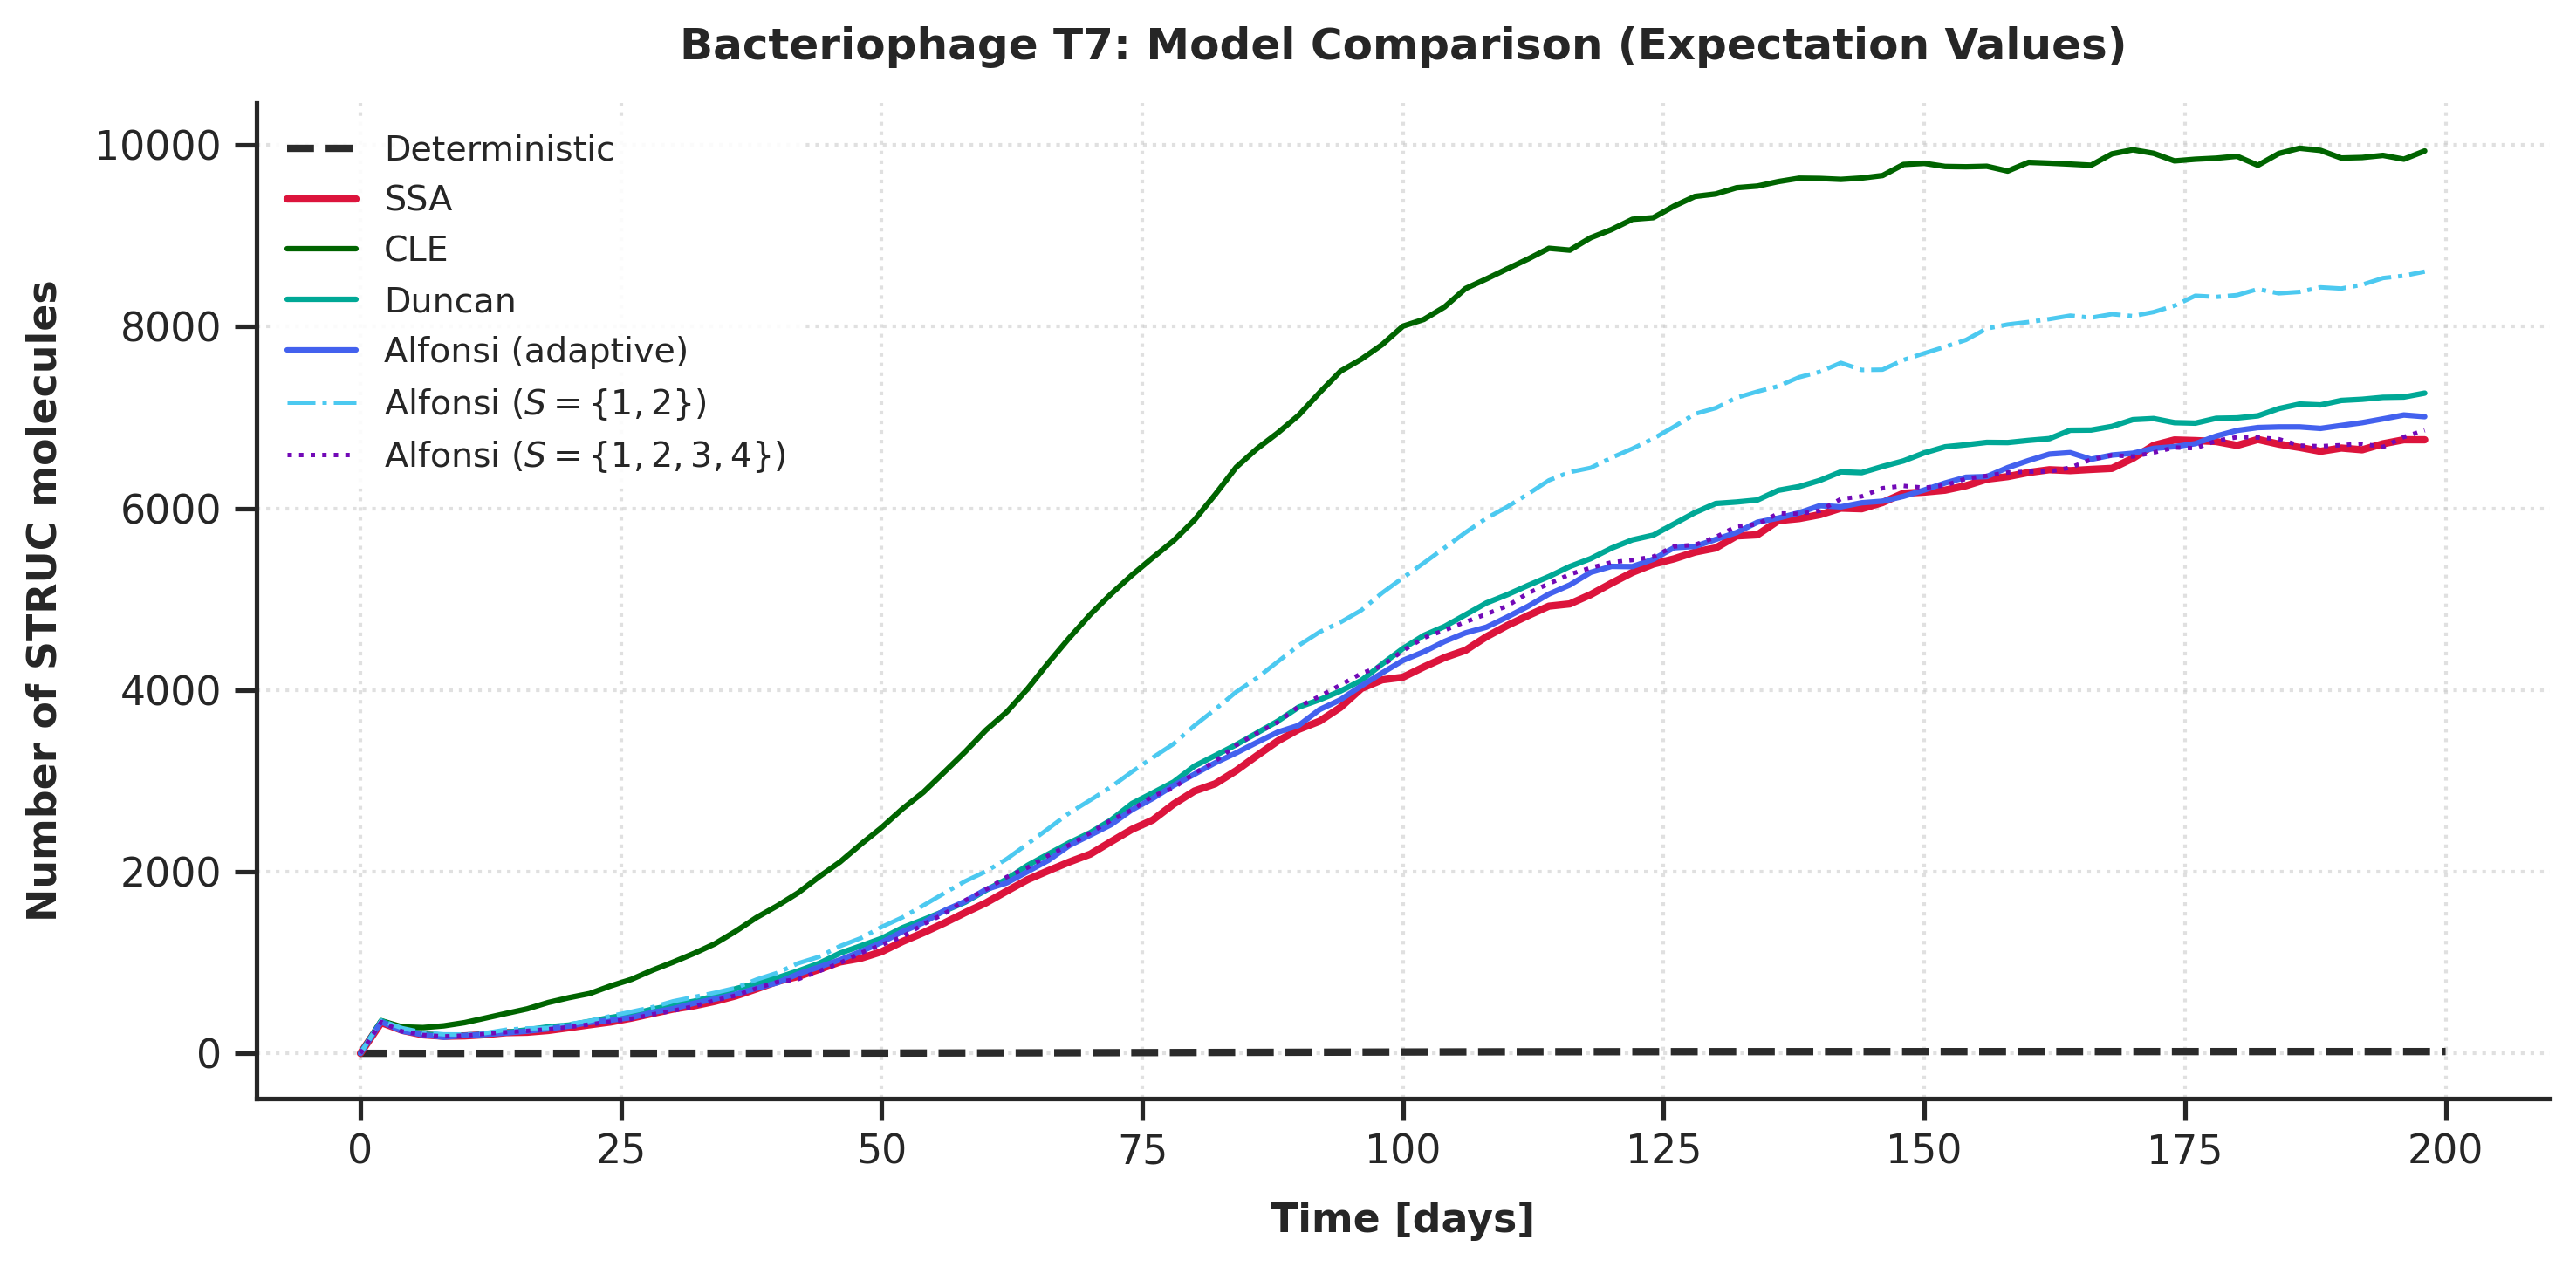

In [20]:
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


t_range = np.arange(0, 200, 2)
sns.set_theme(style="ticks")
fig, ax = plt.subplots(figsize=(10, 5),dpi=300)
ax.plot(bacteriophage.t, tem, label="Deterministic", color="#2b2b2b", linewidth=2, linestyle="--")
ax.plot(t_range, ssa_exp[:,2], label="SSA", color="crimson", linewidth=2)
ax.plot(t_range, cle_exp[:,2], label="CLE", color="darkgreen", linewidth=1.5)
ax.plot(t_range, duncan_exp[:,2], label="Duncan", color="#00a896", linewidth=1.5)
ax.plot(t_range, alfonsi_exp[:,2], label="Alfonsi (adaptive)", color="#4361ee", linewidth=1.5)
ax.plot(t_range, alfonsi_set_small_exp[:,2], label=r"Alfonsi ($S=\{1,2\}$)", color="#4cc9f0", linewidth=1.2, linestyle="-.")
ax.plot(t_range, alfonsi_set_huge_exp[:,2], label=r"Alfonsi ($S=\{1,2,3,4\}$)", color="#7209b7", linewidth=1.2, linestyle=":")
ax.set_xlabel("Time [days]", fontsize=11, fontweight="bold", labelpad=8)
ax.set_ylabel("Number of STRUC molecules", fontsize=11, fontweight="bold", labelpad=8)
ax.set_title("Bacteriophage T7: Model Comparison (Expectation Values)", fontsize=12, pad=12, fontweight="bold")
ax.grid(True, linestyle=":", alpha=0.6)
sns.despine(top=True, right=True)
ax.legend(loc="upper left", frameon=True, facecolor="white", framealpha=0.9, edgecolor="none", fontsize=9.5)
plt.tight_layout()
path2 = os.path.join("/work/scheibe5/bacteriophage_t7", "bacteriophage_model_comparison_struc_exp2.png")
plt.savefig(path2, bbox_inches="tight")
plt.show()

### Probability Distributions over time

#### Bacterophage-Model

In [20]:
path_cle = "/work/scheibe5/bacteriophage_t7/cle/result_cle_bacteriophage.csv"
path_duncan = "/work/scheibe5/bacteriophage_t7/duncan_ssa/result_duncan_ssa_15_25_bacteriophage.csv"
path_alfonsi = "/work/scheibe5/bacteriophage_t7/alfonsi_adaptive/result_alfonsi_adaptive_60_bacteriophage.csv"
path_ssa= "/work/scheibe5/bacteriophage_t7/ssa/result_ssa_bacteriophage.csv"

In [12]:
def fill_time_dict_gen(data, path,n_state, n_simulation, time_points):
    for current_result in stochastinetics.read_in_sim_results_gen(path,n_state):
        for j,ti in enumerate(time_points):
            idx = np.searchsorted(current_result[0], ti)
            idx = np.clip(idx, 1, len(current_result[1]) - 1)
            if abs(current_result[0][idx - 1] - ti) < abs(current_result[0][idx] - ti):
                idx -= 1
            data[ti].append(current_result[1][idx].copy())
    for _,ti in enumerate(time_points):
        data[ti] = np.array(data[ti])
    return data

time_points = [1, 10, 50, 100,150,200]

data_cle = {1: [],10: [],50: [],100: [],150:[],200:[]}
data_cle = fill_time_dict_gen(data_cle, path_cle,4,1000,time_points)

1 simulation runs have been streamed successfully.
2 simulation runs have been streamed successfully.
3 simulation runs have been streamed successfully.
4 simulation runs have been streamed successfully.
5 simulation runs have been streamed successfully.
6 simulation runs have been streamed successfully.
7 simulation runs have been streamed successfully.
8 simulation runs have been streamed successfully.
9 simulation runs have been streamed successfully.
10 simulation runs have been streamed successfully.
11 simulation runs have been streamed successfully.
12 simulation runs have been streamed successfully.
13 simulation runs have been streamed successfully.
14 simulation runs have been streamed successfully.
15 simulation runs have been streamed successfully.
16 simulation runs have been streamed successfully.
17 simulation runs have been streamed successfully.
18 simulation runs have been streamed successfully.
19 simulation runs have been streamed successfully.
20 simulation runs ha

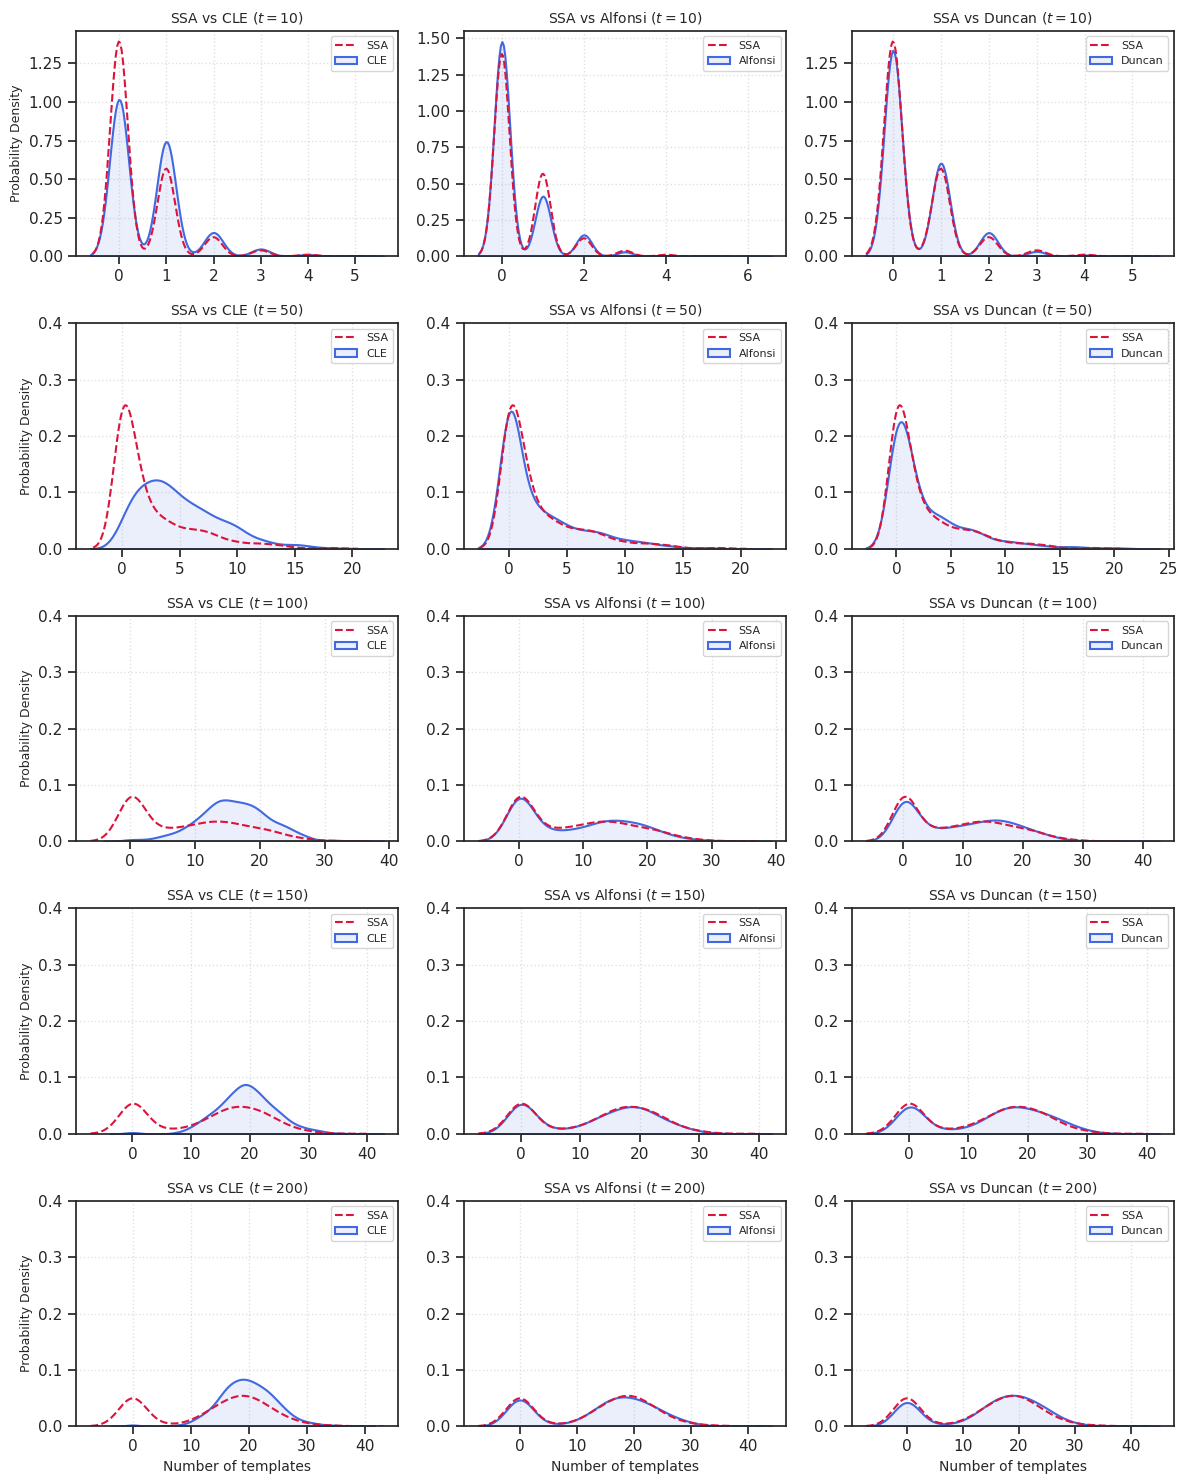

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

time_points = [10, 50, 100,150,200]
n_rows = len(time_points)


fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(12, 3 * n_rows))

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, t in enumerate(time_points):
    ax_left = axes[row_idx, 0]
    ax_mid = axes[row_idx, 1]
    ax_right = axes[row_idx, 2]

    sns.kdeplot(data_ssa[t][:,1],ax=ax_left, color="crimson", linestyle= "--",label="SSA",linewidth=1.5)
    sns.kdeplot(np.round(data_cle[t][:,1]),ax=ax_left,color="royalblue",label="CLE",linewidth=1.5,fill=True,alpha=0.1)
    ax_left.set_title(f"SSA vs CLE ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,1], ax=ax_mid,color="crimson", linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(np.round(data_alfonsi[t][:,1]) ,ax=ax_mid, color="royalblue",label="Alfonsi",linewidth=1.5,fill=True, alpha=0.1)
    ax_mid.set_title(f"SSA vs Alfonsi ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,1], color="crimson", ax=ax_right,linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(data_duncan_ssa[t][:,1], ax=ax_right, color = "royalblue",label="Duncan",linewidth=1.5,fill=True, alpha=0.1)
    ax_right.set_title(f"SSA vs Duncan ($t = {t}$)", fontsize=10)

    ax_left.legend(loc="upper right", fontsize=8, frameon=True)
    ax_mid.legend(loc="upper right", fontsize=8, frameon=True)
    ax_right.legend(loc="upper right", fontsize=8, frameon=True)

    for ax in [ax_left, ax_mid, ax_right]:
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.set_ylabel("")
        ax.set_xlabel("")
        
    if row_idx > 0:     
        ax_left.set_ylim([0,0.4])
        ax_mid.set_ylim([0,0.4])
        ax_right.set_ylim([0,0.4])
    ax_left.set_ylabel("Probability Density", fontsize=9)

for col_idx in range(3):
    axes[-1, col_idx].set_xlabel("Number of templates", fontsize=10)

plt.tight_layout()
plt.savefig("/work/scheibe5/bacteriophage_t7/probability_dist_templates.png")
plt.show()

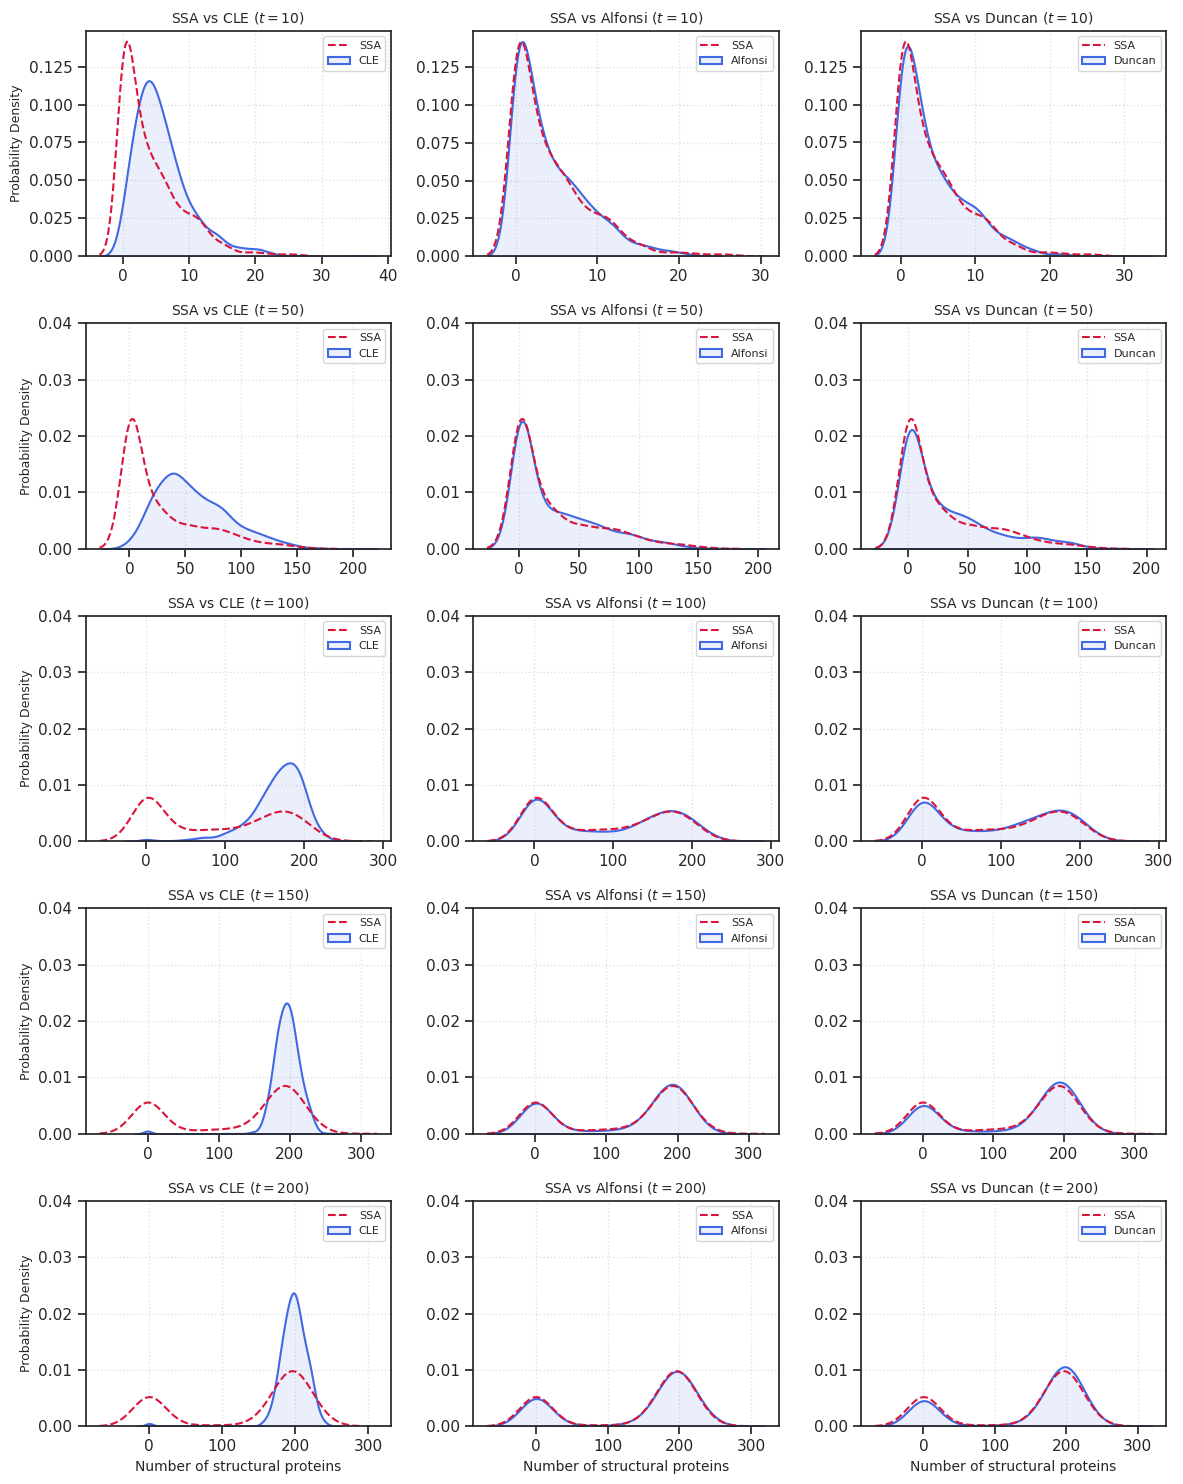

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

time_points = [10, 50, 100,150,200]
n_rows = len(time_points)


fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(12, 3 * n_rows))

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, t in enumerate(time_points):
    ax_left = axes[row_idx, 0]
    ax_mid = axes[row_idx, 1]
    ax_right = axes[row_idx, 2]

    sns.kdeplot(data_ssa[t][:,0],ax=ax_left, color="crimson", linestyle= "--",label="SSA",linewidth=1.5)
    sns.kdeplot(np.round(data_cle[t][:,0]),ax=ax_left,color="royalblue",label="CLE",linewidth=1.5,fill=True,alpha=0.1)
    ax_left.set_title(f"SSA vs CLE ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,0], ax=ax_mid,color="crimson", linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(np.round(data_alfonsi[t][:,0]) ,ax=ax_mid, color="royalblue",label="Alfonsi",linewidth=1.5,fill=True, alpha=0.1)
    ax_mid.set_title(f"SSA vs Alfonsi ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,0], color="crimson", ax=ax_right,linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(data_duncan_ssa[t][:,0], ax=ax_right, color = "royalblue",label="Duncan",linewidth=1.5,fill=True, alpha=0.1)
    ax_right.set_title(f"SSA vs Duncan ($t = {t}$)", fontsize=10)

    ax_left.legend(loc="upper right", fontsize=8, frameon=True)
    ax_mid.legend(loc="upper right", fontsize=8, frameon=True)
    ax_right.legend(loc="upper right", fontsize=8, frameon=True)

    for ax in [ax_left, ax_mid, ax_right]:
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.set_ylabel("")
        ax.set_xlabel("")
        
    if row_idx > 0:     
        ax_left.set_ylim([0,0.04])
        ax_mid.set_ylim([0,0.04])
        ax_right.set_ylim([0,0.04])
    ax_left.set_ylabel("Probability Density", fontsize=9)

for col_idx in range(3):
    axes[-1, col_idx].set_xlabel("Number of structural proteins", fontsize=10)

plt.tight_layout()
plt.savefig("/work/scheibe5/bacteriophage_t7/probability_dist_structs.png")
plt.show()

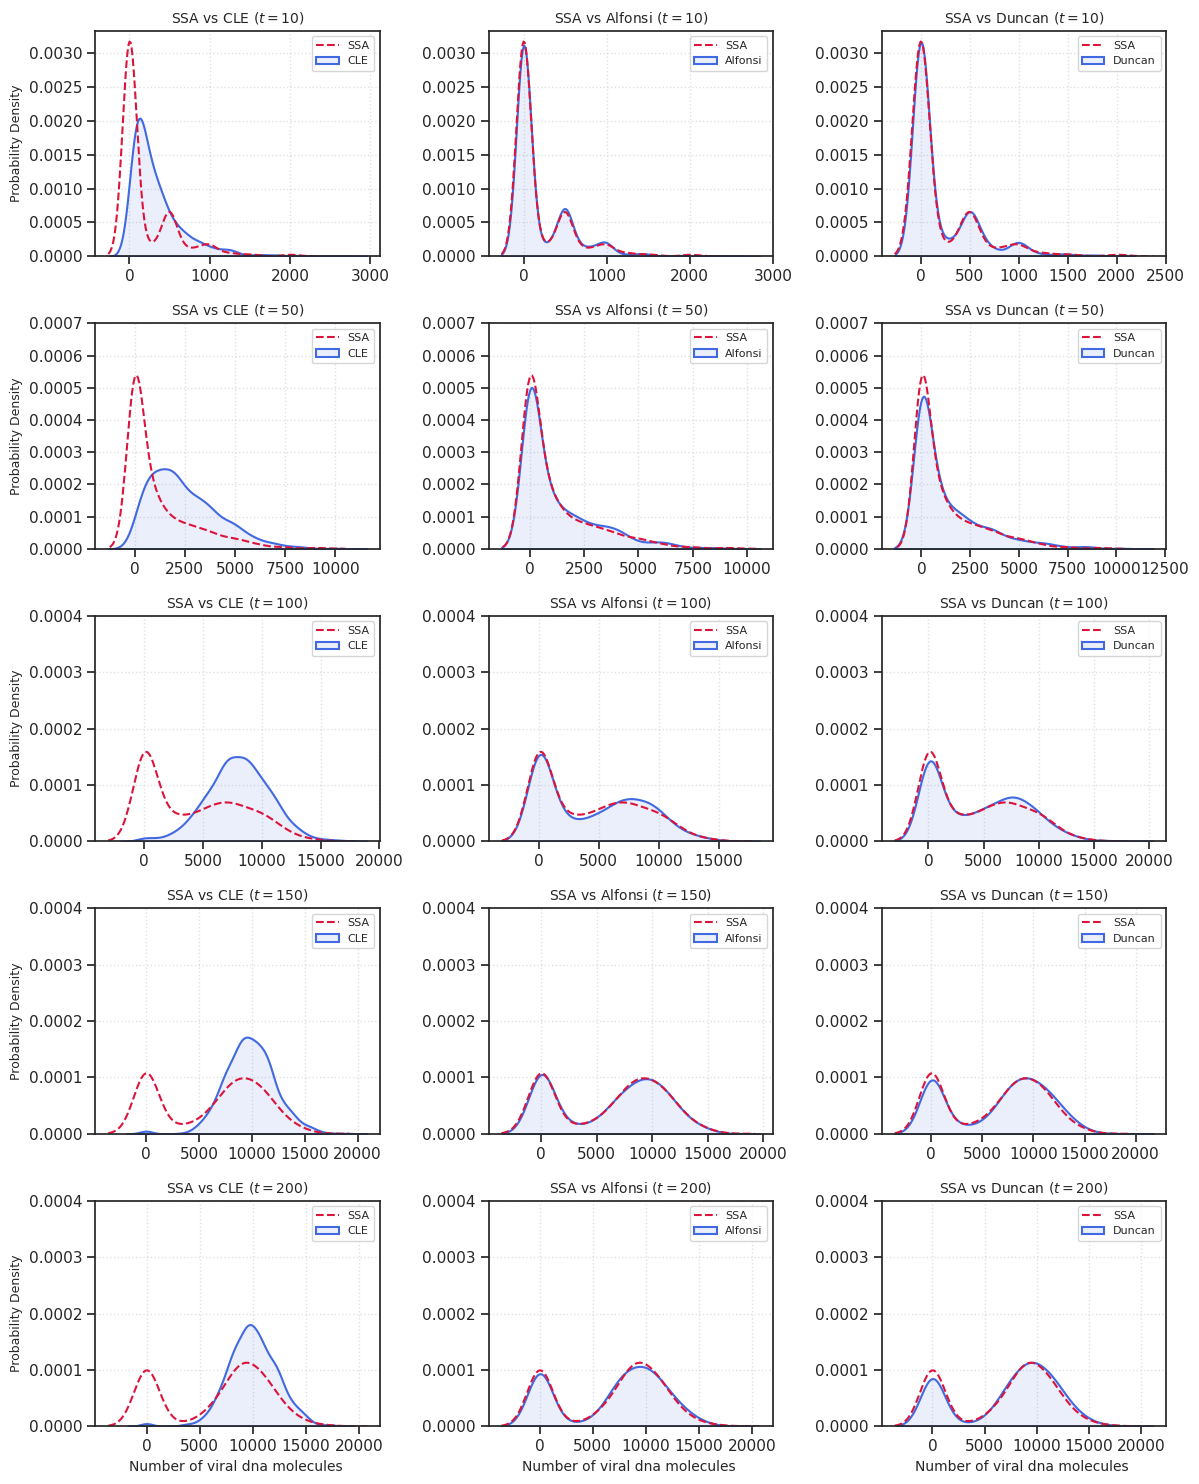

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

time_points = [10, 50, 100,150,200]
n_rows = len(time_points)


fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(12, 3 * n_rows))

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, t in enumerate(time_points):
    ax_left = axes[row_idx, 0]
    ax_mid = axes[row_idx, 1]
    ax_right = axes[row_idx, 2]

    sns.kdeplot(data_ssa[t][:,2],ax=ax_left, color="crimson", linestyle= "--",label="SSA",linewidth=1.5)
    sns.kdeplot(np.round(data_cle[t][:,2]),ax=ax_left,color="royalblue",label="CLE",linewidth=1.5,fill=True,alpha=0.1)
    ax_left.set_title(f"SSA vs CLE ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,2], ax=ax_mid,color="crimson", linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(np.round(data_alfonsi[t][:,2]) ,ax=ax_mid, color="royalblue",label="Alfonsi",linewidth=1.5,fill=True, alpha=0.1)
    ax_mid.set_title(f"SSA vs Alfonsi ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,2], color="crimson", ax=ax_right,linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(data_duncan_ssa[t][:,2], ax=ax_right, color = "royalblue",label="Duncan",linewidth=1.5,fill=True, alpha=0.1)
    ax_right.set_title(f"SSA vs Duncan ($t = {t}$)", fontsize=10)

    ax_left.legend(loc="upper right", fontsize=8, frameon=True)
    ax_mid.legend(loc="upper right", fontsize=8, frameon=True)
    ax_right.legend(loc="upper right", fontsize=8, frameon=True)

    for ax in [ax_left, ax_mid, ax_right]:
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.set_ylabel("")
        ax.set_xlabel("")
        
        
    if row_idx == 1:
        ax_left.set_ylim([0,0.0007])
        ax_mid.set_ylim([0,0.0007])
        ax_right.set_ylim([0,0.0007]) 
    elif row_idx > 1:     
        ax_left.set_ylim([0,0.0004])
        ax_mid.set_ylim([0,0.0004])
        ax_right.set_ylim([0,0.0004])
    ax_left.set_ylabel("Probability Density", fontsize=9)

for col_idx in range(3):
    axes[-1, col_idx].set_xlabel("Number of viral dna molecules ", fontsize=10)

plt.tight_layout()
plt.savefig("/work/scheibe5/bacteriophage_t7/probability_dist_dna.png")
plt.show()

#### Lotka-Volterra

In [4]:
def fill_time_dict_gen(data, path,n_state, n_simulation, time_points):
    for current_result in stochastinetics.read_in_sim_results_gen(path,n_state):
        for j,ti in enumerate(time_points):
            idx = np.searchsorted(current_result[0], ti)
            idx = np.clip(idx, 1, len(current_result[1]) - 1)
            if abs(current_result[0][idx - 1] - ti) < abs(current_result[0][idx] - ti):
                idx -= 1
            data[ti].append(current_result[1][idx].copy())
    for _,ti in enumerate(time_points):
        data[ti] = np.array(data[ti])
    return data

path_cle = "/work/scheibe5/result_lotka_volterra_cle.csv"
path_duncan = "/work/scheibe5/result_lotka_volterra_duncan_15.0_25.0.csv"
path_alfonsi = "/work/scheibe5/result_lotka_volterra_gillespie_500.csv"
path_ssa= "/work/scheibe5/result_lotka_volterra_ssa.csv"

paths = [path_cle, path_duncan, path_alfonsi, path_ssa]
time_points = [1, 2, 3, 4, 5]

data_cle = {1: [], 2: [], 3: [],4: [],5:[]}
data_duncan = {1: [], 2: [], 3: [],4: [],5:[]}
data_alfonsi = {1: [], 2: [], 3: [],4: [],5:[]}
data_ssa = {1: [], 2: [], 3: [],4: [],5:[]}

datas = [data_cle, data_duncan, data_alfonsi, data_ssa]

for i,data in enumerate(datas):
    datas[i] = fill_time_dict_gen(data, paths[i],3,1000,time_points)

1 simulation runs have been streamed successfully.
2 simulation runs have been streamed successfully.
3 simulation runs have been streamed successfully.
4 simulation runs have been streamed successfully.
5 simulation runs have been streamed successfully.
6 simulation runs have been streamed successfully.
7 simulation runs have been streamed successfully.
8 simulation runs have been streamed successfully.
9 simulation runs have been streamed successfully.
10 simulation runs have been streamed successfully.
11 simulation runs have been streamed successfully.
12 simulation runs have been streamed successfully.
13 simulation runs have been streamed successfully.
14 simulation runs have been streamed successfully.
15 simulation runs have been streamed successfully.
16 simulation runs have been streamed successfully.
17 simulation runs have been streamed successfully.
18 simulation runs have been streamed successfully.
19 simulation runs have been streamed successfully.
20 simulation runs ha

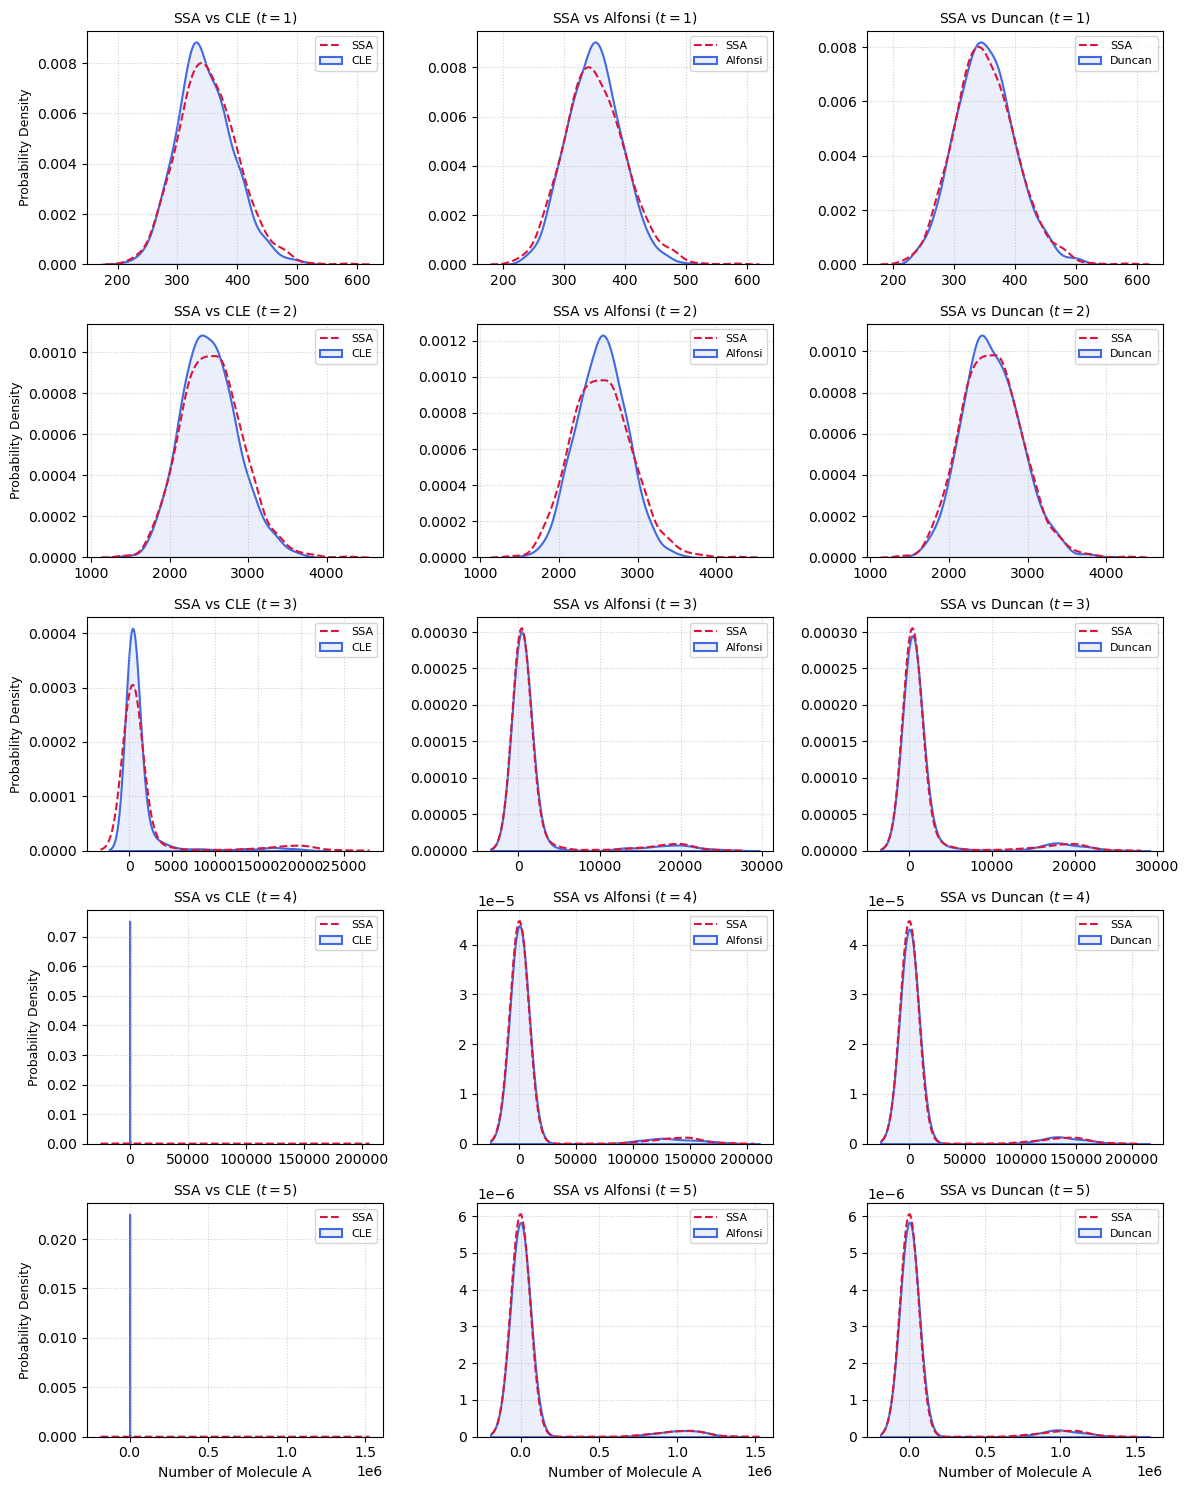

In [10]:
# Molecule - A
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

time_points = [1, 2, 3, 4, 5]
n_rows = len(time_points)


fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(12, 3 * n_rows))

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, t in enumerate(time_points):
    ax_left = axes[row_idx, 0]
    ax_mid = axes[row_idx, 1]
    ax_right = axes[row_idx, 2]

    sns.kdeplot(data_ssa[t][:,0],ax=ax_left, color="crimson", linestyle= "--",label="SSA",linewidth=1.5)
    sns.kdeplot(np.round(data_cle[t][:,0]),ax=ax_left,color="royalblue",label="CLE",linewidth=1.5,fill=True,alpha=0.1)
    ax_left.set_title(f"SSA vs CLE ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,0], ax=ax_mid,color="crimson", linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(np.round(data_alfonsi[t][:,0]) ,ax=ax_mid, color="royalblue",label="Alfonsi",linewidth=1.5,fill=True, alpha=0.1)
    ax_mid.set_title(f"SSA vs Alfonsi ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,0], color="crimson", ax=ax_right,linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(data_duncan_ssa[t][:,0], ax=ax_right, color = "royalblue",label="Duncan",linewidth=1.5,fill=True, alpha=0.1)
    ax_right.set_title(f"SSA vs Duncan ($t = {t}$)", fontsize=10)

    ax_left.legend(loc="upper right", fontsize=8, frameon=True)
    ax_mid.legend(loc="upper right", fontsize=8, frameon=True)
    ax_right.legend(loc="upper right", fontsize=8, frameon=True)

    for ax in [ax_left, ax_mid, ax_right]:
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.set_ylabel("")
        ax.set_xlabel("")
        
    # if row_idx > 0:     
    #     ax_left.set_ylim([0,0.4])
    #     ax_mid.set_ylim([0,0.4])
    #     ax_right.set_ylim([0,0.4])
    ax_left.set_ylabel("Probability Density", fontsize=9)

for col_idx in range(3):
    axes[-1, col_idx].set_xlabel("Number of Molecule A", fontsize=10)

plt.tight_layout()
plt.savefig("/work/scheibe5/probability_dist_A.png")
plt.show()


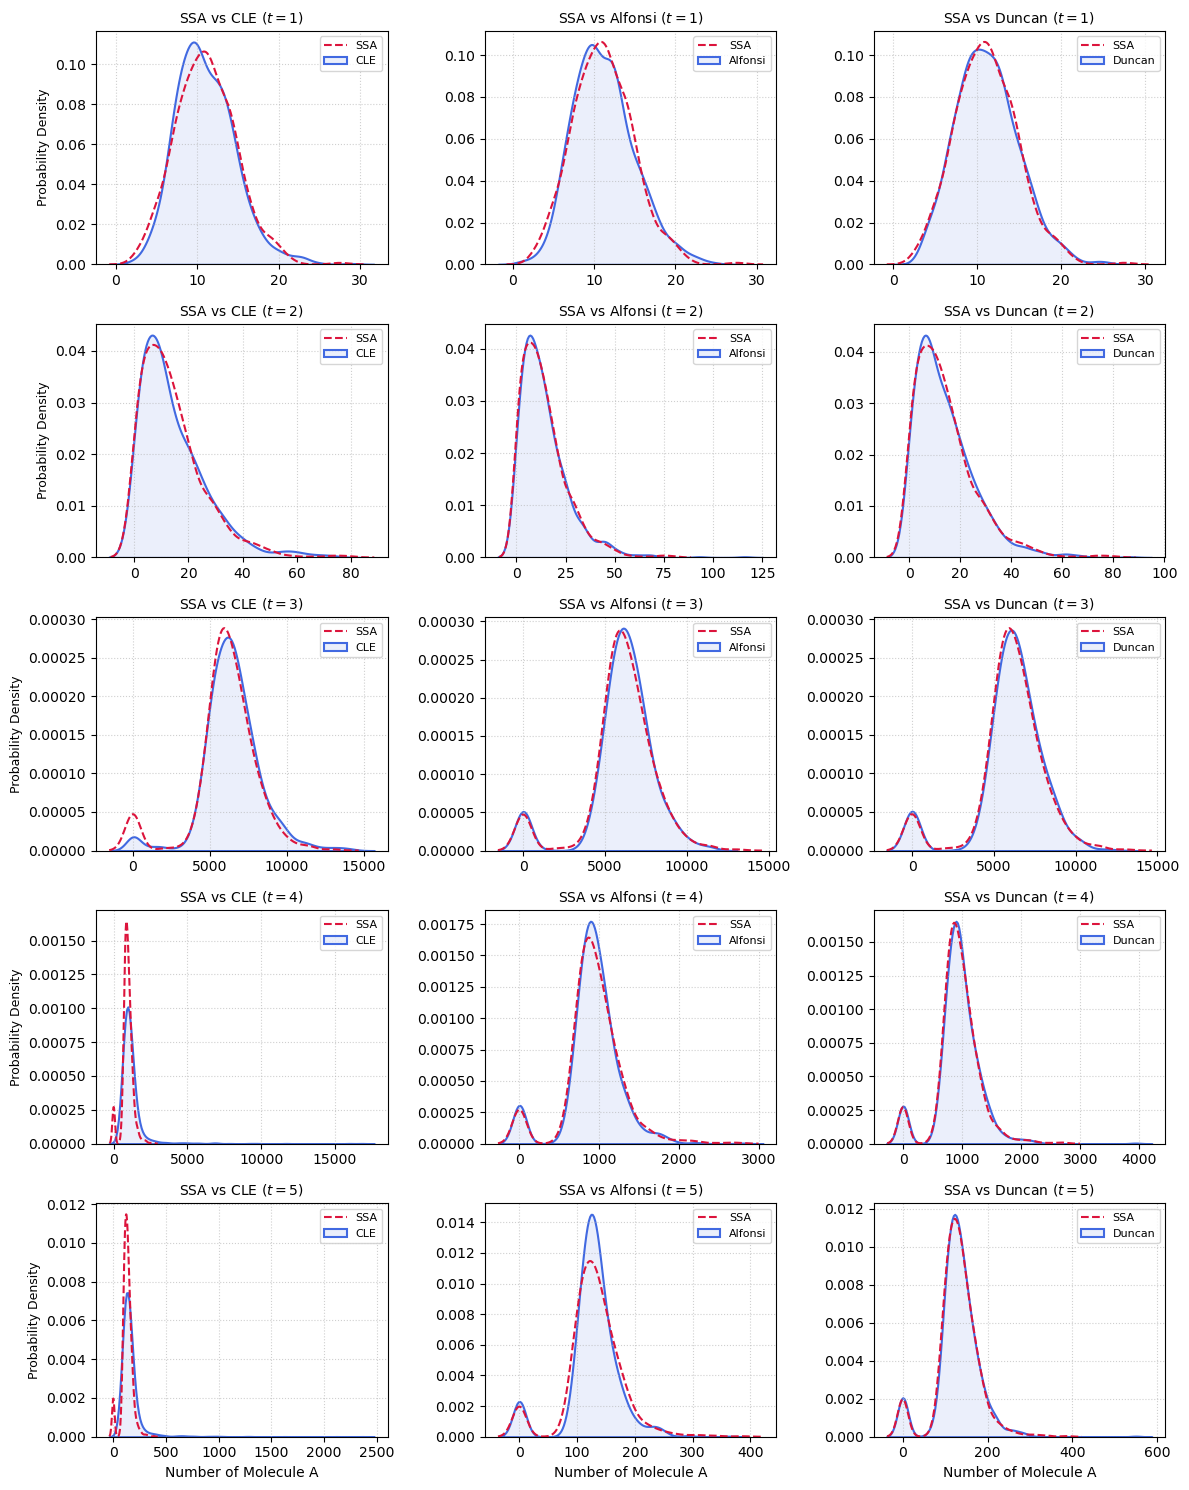

In [14]:
# Molecule - B
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

time_points = [1, 2, 3, 4, 5]
n_rows = len(time_points)


fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(12, 3 * n_rows))

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, t in enumerate(time_points):
    ax_left = axes[row_idx, 0]
    ax_mid = axes[row_idx, 1]
    ax_right = axes[row_idx, 2]

    sns.kdeplot(data_ssa[t][:,1],ax=ax_left, color="crimson", linestyle= "--",label="SSA",linewidth=1.5)
    sns.kdeplot(np.round(data_cle[t][:,1]),ax=ax_left,color="royalblue",label="CLE",linewidth=1.5,fill=True,alpha=0.1)
    ax_left.set_title(f"SSA vs CLE ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,1], ax=ax_mid,color="crimson", linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(np.round(data_alfonsi[t][:,1]) ,ax=ax_mid, color="royalblue",label="Alfonsi",linewidth=1.5,fill=True, alpha=0.1)
    ax_mid.set_title(f"SSA vs Alfonsi ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,1], color="crimson", ax=ax_right,linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(data_duncan_ssa[t][:,1], ax=ax_right, color = "royalblue",label="Duncan",linewidth=1.5,fill=True, alpha=0.1)
    ax_right.set_title(f"SSA vs Duncan ($t = {t}$)", fontsize=10)

    ax_left.legend(loc="upper right", fontsize=8, frameon=True)
    ax_mid.legend(loc="upper right", fontsize=8, frameon=True)
    ax_right.legend(loc="upper right", fontsize=8, frameon=True)

    for ax in [ax_left, ax_mid, ax_right]:
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.set_ylabel("")
        ax.set_xlabel("")
        
    # if row_idx > 0:     
    #     ax_left.set_ylim([0,0.4])
    #     ax_mid.set_ylim([0,0.4])
    #     ax_right.set_ylim([0,0.4])
    ax_left.set_ylabel("Probability Density", fontsize=9)

for col_idx in range(3):
    axes[-1, col_idx].set_xlabel("Number of Molecule A", fontsize=10)

plt.tight_layout()
plt.savefig("/work/scheibe5/probability_dist_B.png")
plt.show()


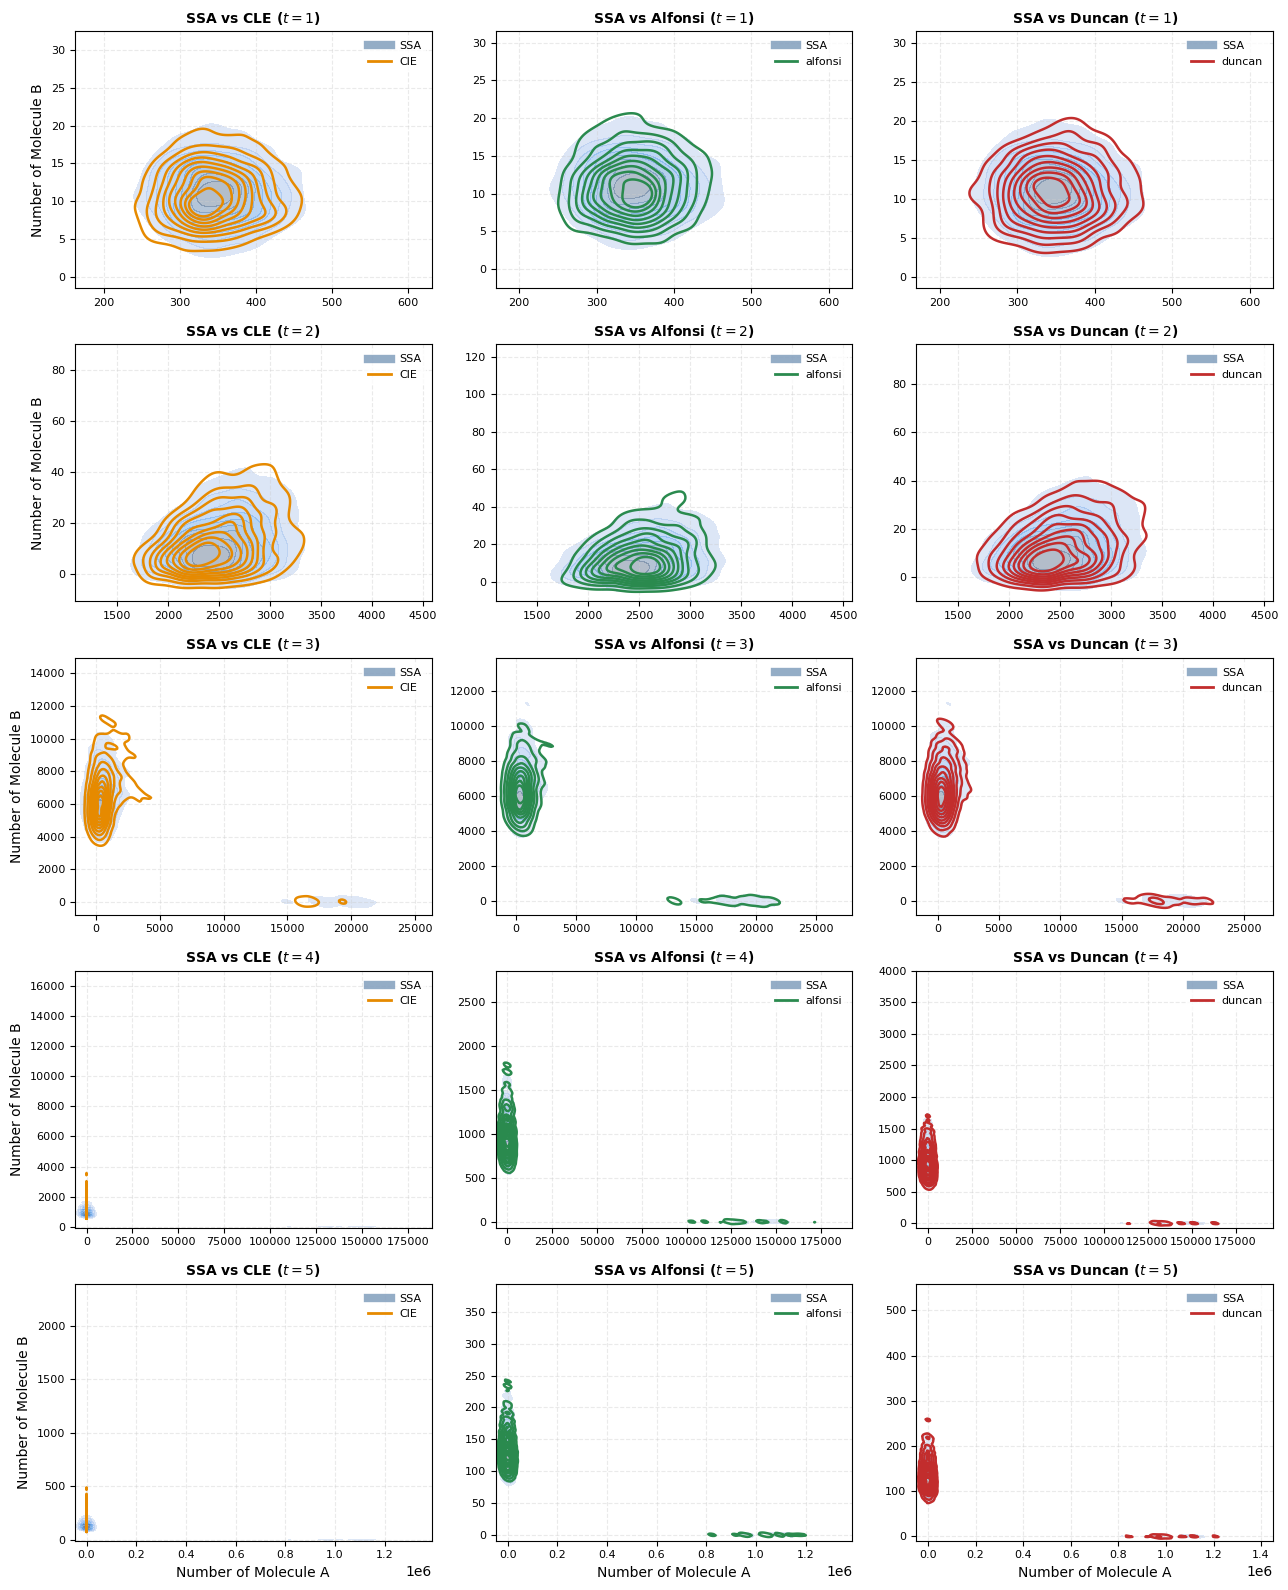

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D

time_points = [1, 2, 3, 4, 5]
n_rows = len(time_points)

c_ssa = "#2b5c8f"      
c_cle = "#e68a00"      
c_alfonsi = "#2a8a4e"  
c_duncan = "#c22d2d"

smoothings= [1, 0.9,0.4,0.2,0.2]

fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(13, 3.2 * n_rows))

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, t in enumerate(time_points):
    ax_left = axes[row_idx, 0]
    ax_mid = axes[row_idx, 1]
    ax_right = axes[row_idx, 2]

    sns.kdeplot(x=data_ssa[t][:,0], y=data_ssa[t][:,1], ax=ax_left, fill=True, alpha=0.4, color=c_ssa, thresh=0.1, bw_adjust=smoothings[row_idx])
    sns.kdeplot(x=np.round(data_cle[t][:,0]), y=np.round(data_cle[t][:,1]), ax=ax_left, fill=False, color=c_cle, thresh=0.1, linewidths=1.8, bw_adjust=smoothings[row_idx])
    ax_left.set_title(f"SSA vs CLE ($t = {t}$)", fontsize=10, fontweight="semibold")

    legend_elements_left = [
        Line2D([0], [0], color=c_ssa, lw=6, alpha=0.5, label="SSA"),
        Line2D([0], [0], color=c_cle, lw=2, label="ClE")
    ]
    ax_left.legend(handles=legend_elements_left, loc="upper right", fontsize=8, frameon=True, facecolor="white", edgecolor="none")

    sns.kdeplot(x=data_ssa[t][:,0], y=data_ssa[t][:,1], ax=ax_mid, fill=True, alpha=0.4, color=c_ssa, thresh=0.1, bw_adjust=smoothings[row_idx])
    sns.kdeplot(x=np.round(data_alfonsi[t][:,0]), y=np.round(data_alfonsi[t][:,1]), ax=ax_mid, fill=False, color=c_alfonsi, thresh=0.1, linewidths=1.8, bw_adjust=smoothings[row_idx])
    ax_mid.set_title(f"SSA vs Alfonsi ($t = {t}$)", fontsize=10, fontweight="semibold")

    legend_elements_mid = [
        Line2D([0], [0], color=c_ssa, lw=6, alpha=0.5, label="SSA"),
        Line2D([0], [0], color=c_alfonsi, lw=2, label="alfonsi")
    ]
    ax_mid.legend(handles=legend_elements_mid, loc="upper right", fontsize=8, frameon=True, facecolor="white", edgecolor="none")

    sns.kdeplot(x=data_ssa[t][:,0], y=data_ssa[t][:,1], ax=ax_right, fill=True, alpha=0.4, color=c_ssa, thresh=0.1, bw_adjust=smoothings[row_idx])
    sns.kdeplot(x=data_duncan_ssa[t][:,0], y=data_duncan_ssa[t][:,1], ax=ax_right, fill=False, color=c_duncan, thresh=0.1, linewidths=1.8, bw_adjust=smoothings[row_idx])
    ax_right.set_title(f"SSA vs Duncan ($t = {t}$)", fontsize=10, fontweight="semibold")

    legend_elements_right = [
        Line2D([0], [0], color=c_ssa, lw=6, alpha=0.5, label="SSA"),
        Line2D([0], [0], color=c_duncan, lw=2, label="duncan")
    ]
    ax_right.legend(handles=legend_elements_right, loc="upper right", fontsize=8, frameon=True, facecolor="white", edgecolor="none")

    for ax in [ax_left, ax_mid, ax_right]:
        ax.grid(True, linestyle="--", alpha=0.4, color="#cccccc")
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.tick_params(labelsize=8)
        
    ax_left.set_ylabel("Number of Molecule B", fontsize=10, fontweight="medium")

for col_idx in range(3):
    axes[-1, col_idx].set_xlabel("Number of Molecule A", fontsize=10, fontweight="medium")

plt.tight_layout()
plt.savefig("/work/scheibe5/probability_dist_B.png", dpi=300)
plt.show()